<a href="https://colab.research.google.com/github/Mahmud394/Global-Life-Expectancy/blob/main/02_data_cleaning_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Data Cleaning and Preprocessing

**DS331 · Introduction to Data Science**

Real-world data is messy: values are missing, types are wrong, rows are duplicated, and some numbers are simply impossible. Data scientists spend a large share of their time cleaning — and the quality of every later step (statistics, plots, conclusions) depends on it. **Garbage in, garbage out.**

In this notebook you will learn how to:

1. [Audit a dataset for problems](#1)
2. [Handle missing values](#2)
3. [Remove duplicates](#3)
4. [Fix data types](#4)
5. [Clean text columns and rename things](#5)
6. [Detect and handle outliers](#6)
7. [Save the cleaned dataset](#7)
8. [Try it yourself ✏️](#8)

**Dataset:** the *Titanic* passenger list — 891 passengers, with age, ticket fare, class, and whether they survived. A classic, and genuinely messy: about 20% of ages are missing.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<a id="1"></a>
## 1. Auditing: find the problems first

Cleaning starts with a diagnosis, not with deleting things. Run the standard checks from Lab 1:

In [2]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Spotted from `info()` alone:
- `age` has 714 non-null values out of 891 → **177 missing**.
- `deck` has only 203 non-null values → **77% missing**!
- `embarked` / `embark_town` are missing 2 values.

### Counting missing values explicitly

`isna()` returns True/False for every cell; summing counts the Trues (True counts as 1).

In [3]:
missing = titanic.isna().sum()
missing_pct = (titanic.isna().mean() * 100).round(1)

pd.DataFrame({"missing_count": missing, "missing_%": missing_pct}).sort_values(
    "missing_count", ascending=False
)

,missing_count,missing_%
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2
sex,0,0.0
pclass,0,0.0
survived,0,0.0
fare,0,0.0
parch,0,0.0
sibsp,0,0.0


### Visualizing missingness

A heatmap of `isna()` shows *where* the holes are — each bright line is a missing value. Patterns matter: scattered holes are easier to handle than entire missing blocks.

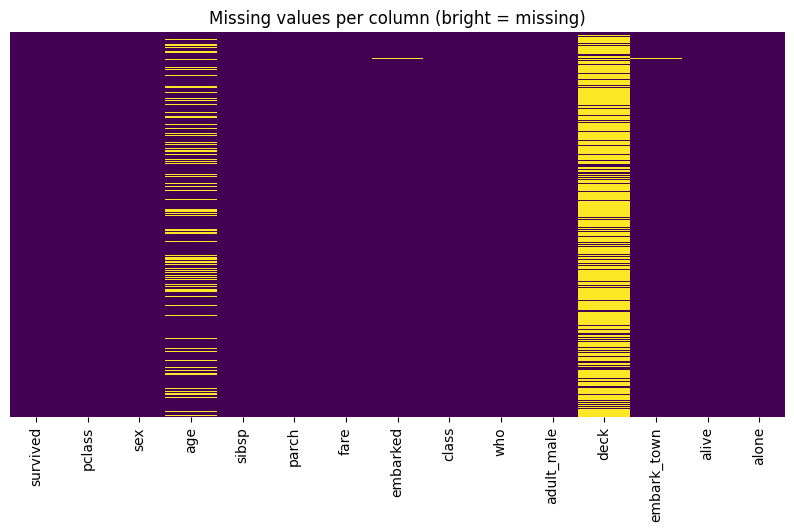

In [4]:
plt.figure(figsize=(10, 5))
sns.heatmap(titanic.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values per column (bright = missing)")
plt.show()

<a id="2"></a>
## 2. Handling missing values

There are two families of strategies: **drop** the missing data, or **fill** it (called *imputation*). Which is right depends on *how much* is missing and *why*.

| Situation | Sensible strategy |
|---|---|
| A column is mostly missing (like `deck`, 77%) | drop the **column** |
| A few rows are missing in an important column | drop those **rows** |
| A moderate share missing in a numeric column | fill with **median** (or mean) |
| A moderate share missing in a categorical column | fill with the **mode** or a label like `"Unknown"` |

We always work on a **copy**, so the raw data stays untouched and we can re-run cells safely:

In [5]:
df = titanic.copy()

### 2.1 Dropping

`dropna()` removes rows (default) or columns (`axis=1`) containing missing values.

> ⚠️ **Common mistake:** calling `df.dropna()` with no arguments drops every row that has *any* missing value — here that would silently delete most of the dataset. Always check the shape before and after.

In [6]:
print("if we dropped every row with any NaN:", titanic.dropna().shape, "<- only ~180 rows left!")

# Drop the 'deck' column: 77% missing is too much to fill credibly
df = df.drop(columns=["deck"])

# Drop the 2 rows where 'embarked' is missing: a tiny, safe loss
df = df.dropna(subset=["embarked"])

print("our shape after targeted cleaning:  ", df.shape)

if we dropped every row with any NaN: (182, 15) <- only ~180 rows left!
our shape after targeted cleaning:   (889, 14)


### 2.2 Filling (imputation)

`age` is missing for ~20% of passengers — too many rows to throw away. We fill instead.

For a numeric column the **median** is usually safer than the mean because it is not pulled around by outliers.

In [7]:
print("age before filling -> missing:", df["age"].isna().sum(),
      "| median:", df["age"].median())

df["age"] = df["age"].fillna(df["age"].median())

print("age after filling  -> missing:", df["age"].isna().sum())

age before filling -> missing: 177 | median: 28.0
age after filling  -> missing: 0


Other `fillna` variants you will meet:

```python
df["col"].fillna(0)                            # a constant
df["col"].fillna(df["col"].mean())             # the mean
df["col"].fillna(df["col"].mode()[0])          # most frequent value (note the [0])
df["col"].ffill()                              # copy the previous value down (time series)
```

> ⚠️ **Be honest in your report.** Imputation invents data. Always *state* what you filled and how ("age: 177 missing values filled with the median, 28.0") — never hide it.

In [8]:
# Final check: no missing values left
df.isna().sum().sum()

np.int64(0)

<a id="3"></a>
## 3. Duplicates

Duplicate rows usually come from data-entry or merging mistakes, and they bias every count and average.

In [9]:
print("duplicated rows:", df.duplicated().sum())

duplicated rows: 116


In [10]:
# Look at a few of them before deciding anything
df[df.duplicated(keep=False)].sort_values(["age", "fare"]).head(6)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,Cherbourg,yes,False
644,1,3,female,0.75,2,1,19.2583,C,Third,child,False,Cherbourg,yes,False
163,0,3,male,17.00,0,0,8.6625,S,Third,man,True,Southampton,no,True
500,0,3,male,17.00,0,0,8.6625,S,Third,man,True,Southampton,no,True
844,0,3,male,17.00,0,0,8.6625,S,Third,man,True,Southampton,no,True
144,0,2,male,18.00,0,0,11.5000,S,Second,man,True,Southampton,no,True


Here the "duplicates" are passengers who happen to share every recorded attribute — the dataset has no name/ID column to tell them apart. In the *original* Titanic data (with names) these are different people, so we **keep** them.

That is the lesson: **inspect duplicates before dropping them.** When they really are repeated records, this removes them:

```python
df = df.drop_duplicates()                    # exact duplicate rows
df = df.drop_duplicates(subset=["user_id"])  # duplicates by a key column
```

<a id="4"></a>
## 4. Fixing data types

Wrong types cause subtle bugs: you cannot compute the mean of a number stored as text, and a date stored as text cannot be sorted chronologically.

In [11]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


### 4.1 `astype()` — direct conversion

`survived` and `pclass` are stored as integers, but they are really **categories** (you would never compute "average passenger class = 2.31" and present it as meaningful). The `category` dtype documents this and saves memory.

In [12]:
df["survived"] = df["survived"].astype("category")
df["pclass"] = df["pclass"].astype("category")
df[["survived", "pclass"]].dtypes

,0
survived,category
pclass,category


### 4.2 Numbers trapped in text — `pd.to_numeric`

A very common situation with messy CSVs: a numeric column arrives as `object` because some entries contain junk. A small fabricated example:

In [13]:
prices = pd.Series(["12.5", "8.99", "n/a", "15.0", "?"])
print(prices.dtype)                      # object = text!

clean_prices = pd.to_numeric(prices, errors="coerce")   # junk becomes NaN
clean_prices

object


,0
0,12.50
1,8.99
2,NaN
3,15.00
4,NaN


`errors="coerce"` converts anything unparseable to `NaN` — which you then handle with the Section 2 toolbox. Sometimes you must strip symbols first:

```python
df["price"] = df["price"].str.replace("$", "", regex=False).str.replace(",", "")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
```

### 4.3 Dates — `pd.to_datetime`

Dates stored as text become powerful once converted (we exploit this fully in Lab 3):

In [14]:
dates = pd.Series(["2024-01-15", "2024-02-03", "2024-03-21"])
dates = pd.to_datetime(dates)
print(dates.dtype)
dates.dt.day_name()

datetime64[ns]


,0
0,Monday
1,Saturday
2,Thursday


<a id="5"></a>
## 5. Cleaning text and renaming

### 5.1 The `.str` accessor

Text columns often hide inconsistencies — extra spaces, mixed capitalization — which make `"Yes"`, `"yes "` and `"YES"` count as three different values.

In [15]:
messy_text = pd.Series(["  Male", "female", "MALE  ", " Female", "male"])

cleaned = messy_text.str.strip().str.lower()
print(cleaned.tolist())
print(cleaned.value_counts())

['male', 'female', 'male', 'female', 'male']
male      3
female    2
Name: count, dtype: int64


The pattern: `.str.strip()` removes surrounding whitespace, `.str.lower()` unifies the case. Also useful: `.str.replace(...)`, `.str.contains(...)`, `.str.split(...)`.

### 5.2 Renaming columns

Clear, consistent column names (lowercase, underscores, no spaces) make every later line of code easier to write.

In [16]:
df = df.rename(columns={"sibsp": "siblings_spouses", "parch": "parents_children"})
list(df.columns)

['survived',
 'pclass',
 'sex',
 'age',
 'siblings_spouses',
 'parents_children',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone']

To clean *all* names at once (very handy for datasets with names like `" Total Price ($) "`):

```python
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
```

<a id="6"></a>
## 6. Outliers

An **outlier** is a value far away from the rest. Two very different kinds:

- **Errors** — a human age of 999, a negative price. Fix or remove.
- **Real but extreme** — a genuinely expensive ticket. Usually **keep** (it is information!), but be aware it can dominate means and stretch plots.

### 6.1 Spotting outliers

`describe()` and a **boxplot** are the standard tools. In a boxplot, the box spans the middle 50% of the data and the dots beyond the whiskers are potential outliers.

In [17]:
df["fare"].describe()

,fare
count,889.000000
mean,32.096681
std,49.697504
min,0.000000
25%,7.895800
50%,14.454200
75%,31.000000
max,512.329200


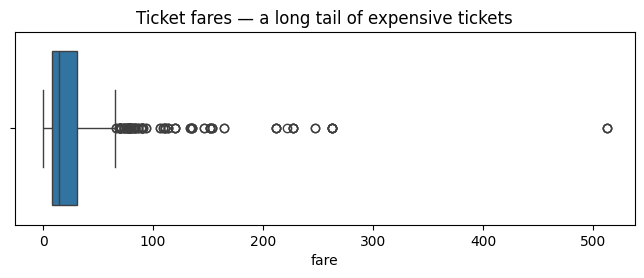

In [18]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df["fare"])
plt.title("Ticket fares — a long tail of expensive tickets")
plt.show()

The median fare is ~14, yet the maximum is 512 — a few passengers paid enormous fares.

### 6.2 The IQR rule — a standard definition

The most common rule of thumb flags values more than 1.5 × IQR beyond the quartiles, where IQR = Q3 − Q1 (exactly the boxplot's whisker rule):

In [19]:
q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"flagged as outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

IQR bounds: [-26.8, 65.7]
flagged as outliers: 114 rows (12.8%)


### 6.3 What to do about them

These expensive fares are **real** (first-class suites), so we keep them — and note the skew for our plots. If you do need to limit their influence, the gentle option is **capping** rather than deleting:

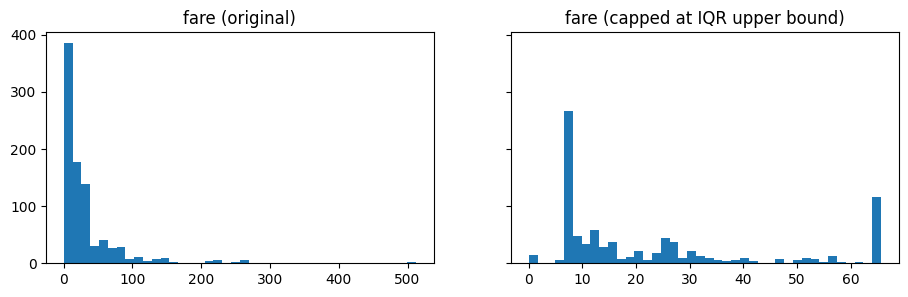

In [20]:
df["fare_capped"] = df["fare"].clip(upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
axes[0].hist(df["fare"], bins=40)
axes[0].set_title("fare (original)")
axes[1].hist(df["fare_capped"], bins=40)
axes[1].set_title("fare (capped at IQR upper bound)")
plt.show()

> ⚠️ **Never silently delete outliers** just to make plots prettier. In your report, state the rule you used and how many rows were affected.

<a id="7"></a>
## 7. Saving the cleaned dataset

Save the result so the next notebook (and your future self) can start from clean data. `index=False` avoids writing the row numbers as an extra column.

In [21]:
df.to_csv("titanic_clean.csv", index=False)

# Read it back to confirm the round trip worked
check = pd.read_csv("titanic_clean.csv")
print("saved and reloaded:", check.shape)
check.head(3)

saved and reloaded: (889, 15)


,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked,class,who,adult_male,embark_town,alive,alone,fare_capped
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,7.2500
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,65.6563
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,7.9250


### The cleaning checklist for your report

For your assigned dataset, walk through exactly what we did here:

1. `info()` + `isna().sum()` — what is missing, what has the wrong type?
2. Decide per column: drop or fill? **Write down your choice and the reason.**
3. Check duplicates — inspect before dropping.
4. Fix dtypes (numbers, categories, dates).
5. Clean text columns; standardize column names.
6. Look for outliers; decide keep / cap / remove — and say so.
7. Save the cleaned file and use it for everything that follows.

<a id="8"></a>
## 8. Try it yourself ✏️

Below is a small, deliberately messy dataset. Apply the full checklist to it.

In [22]:
messy = pd.DataFrame({
    "Name ": ["  alice", "Bob", "bob", "CHARLIE ", "dana", "Bob", None],
    "Age": ["25", "32", "32", "199", "28", "32", "41"],
    "City": ["Dhaka", " dhaka", "Chittagong", "Dhaka", None, " dhaka", "Sylhet"],
    "Salary($)": ["50,000", "62,000", "62,000", "58,000", "n/a", "62,000", "71,000"],
})
messy

,Name,Age,City,Salary($)
0,alice,25,Dhaka,"50,000"
1,Bob,32,dhaka,"62,000"
2,bob,32,Chittagong,"62,000"
3,CHARLIE,199,Dhaka,"58,000"
4,dana,28,None,n/a
5,Bob,32,dhaka,"62,000"
6,None,41,Sylhet,"71,000"


**Exercise 1.** Standardize the column names: strip spaces, lowercase, and replace `($)` so the names are valid identifiers like `salary`.

**Exercise 2.** `Age` is stored as text and contains an impossible value. Convert it to numeric and deal with the 199. Justify your choice.

**Exercise 3.** Clean the `Name` and `City` text (strip, consistent case), then find and remove the truly duplicated row.

**Exercise 4.** Convert `Salary($)` to numeric (careful: commas and `"n/a"`), then fill the missing salary with a value you think is reasonable — and write one sentence defending the choice.

**Exercise 5.** Save your cleaned DataFrame to `messy_clean.csv` and reload it to verify.

In [23]:
# Exercise 1
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace("($)", "", regex=False)
)

print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'siblings_spouses',
       'parents_children', 'fare', 'embarked', 'class', 'who', 'adult_male',
       'embark_town', 'alive', 'alone', 'fare_capped'],
      dtype='object')


In [24]:
# Exercise 2
df["age"] = pd.to_numeric(df["age"], errors="coerce")

df.loc[df["age"] == 199, "age"] = np.nan

df["age"].fillna(df["age"].median(), inplace=True)

print(df)

    survived pclass     sex   age  siblings_spouses  parents_children  \
0          0      3    male  22.0                 1                 0   
1          1      1  female  38.0                 1                 0   
2          1      3  female  26.0                 0                 0   
3          1      1  female  35.0                 1                 0   
4          0      3    male  35.0                 0                 0   
..       ...    ...     ...   ...               ...               ...   
886        0      2    male  27.0                 0                 0   
887        1      1  female  19.0                 0                 0   
888        0      3  female  28.0                 1                 2   
889        1      1    male  26.0                 0                 0   
890        0      3    male  32.0                 0                 0   

        fare embarked   class    who  adult_male  embark_town alive  alone  \
0     7.2500        S   Third    man        T

/tmp/ipykernel_2113/301229998.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


In [29]:
messy_df = messy.copy()

# First, correctly apply Exercise 1 to 'messy_df' to standardize column names
messy_df.columns = (
    messy_df.columns.str.strip()
                 .str.lower()
                 .str.replace('($)', '', regex=False)
)

# Then, correctly apply Exercise 2 to 'messy_df' for the 'age' column
messy_df["age"] = pd.to_numeric(messy_df["age"], errors="coerce")
messy_df.loc[messy_df["age"] == 199, "age"] = np.nan
messy_df["age"].fillna(messy_df["age"].median(), inplace=True)


# Now, apply Exercise 3 to 'messy_df'
messy_df["name"] = messy_df["name"].str.strip().str.title()
messy_df["city"] = messy_df["city"].str.strip().str.title()

messy_df = messy_df.drop_duplicates()

print(messy_df)

      name   age        city  salary
0    Alice  25.0       Dhaka  50,000
1      Bob  32.0       Dhaka  62,000
2      Bob  32.0  Chittagong  62,000
3  Charlie  32.0       Dhaka  58,000
4     Dana  28.0        None     n/a
6     None  41.0      Sylhet  71,000


/tmp/ipykernel_2113/72383456.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  messy_df["age"].fillna(messy_df["age"].median(), inplace=True)


In [31]:
# Exercise 4
messy_df["salary"] = (
    messy_df["salary"]
      .astype(str)
      .str.replace(",", "")
      .replace("n/a", np.nan)
)

messy_df["salary"] = pd.to_numeric(messy_df["salary"], errors="coerce")

messy_df["salary"].fillna(messy_df["salary"].median(), inplace=True)

print(messy_df)

      name   age        city   salary
0    Alice  25.0       Dhaka  50000.0
1      Bob  32.0       Dhaka  62000.0
2      Bob  32.0  Chittagong  62000.0
3  Charlie  32.0       Dhaka  58000.0
4     Dana  28.0        None  62000.0
6     None  41.0      Sylhet  71000.0


/tmp/ipykernel_2113/192657730.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  messy_df["salary"].fillna(messy_df["salary"].median(), inplace=True)


In [33]:
# Exercise 5
messy_df.to_csv("messy_clean.csv", index=False)

check = pd.read_csv("messy_clean.csv")

print(check.head())

      name   age        city   salary
0    Alice  25.0       Dhaka  50000.0
1      Bob  32.0       Dhaka  62000.0
2      Bob  32.0  Chittagong  62000.0
3  Charlie  32.0       Dhaka  58000.0
4     Dana  28.0         NaN  62000.0


---
**Next lab:** clean data is the foundation — now we *create new columns* that make analysis sharper: **Lab 3 — Feature Engineering**.